# HW 5: SVM

In [2]:
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve,auc
from sklearn import metrics
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd

In [3]:
%load_ext pycodestyle_magic

In [4]:
def plot_cv_results(cv_results, param_x, param_z, metric='mean_test_score'):
    """
    cv_results - cv_results_ attribute of a GridSearchCV instance (or similar)
    param_x - name of grid search parameter to plot on x axis
    param_z - name of grid search parameter to plot by line color
    """
    cv_results = pd.DataFrame(cv_results)
    col_x = 'param_' + param_x
    col_z = 'param_' + param_z
    fig, ax = plt.subplots(1, 1, figsize=(11, 8))
    sns.pointplot(x=col_x, y=metric, hue=col_z, data=cv_results, ci=99, n_boot=64, ax=ax)
    plt.xticks(rotation=90)
    ax.set_title("CV Grid Search Results")
    ax.set_xlabel(param_x)
    ax.set_ylabel(metric)
    ax.legend(title=param_z)
    return fig

## Import data

In [5]:
df = pd.read_csv('data/credit_scoring_train.csv')
df_test = pd.read_csv('data/credit_scoring_test.csv')

In [6]:
df.head()

,client_id,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
0,0,0.177772,50.5,11,0,3.0,2,0,5511.073207,0.898558,0
1,1,0.278636,65.3,9,2,2.0,0,0,4544.015711,0.010220,0
2,2,0.000000,55.4,0,0,0.0,0,0,NaN,1.005478,0
3,3,0.285555,53.4,12,2,1.0,0,0,13253.922692,1.309580,0
4,4,0.592800,56.5,10,6,0.0,0,0,12581.109054,0.045905,0


### Checking for na values

In [7]:
df.isnull().sum()

client_id                    0
DIR                          0
Age                          0
NumLoans                     0
NumRealEstateLoans           0
NumDependents             1527
Num30-59Delinquencies        0
Num60-89Delinquencies        0
Income                   11892
BalanceToCreditLimit         0
Delinquent90                 0
dtype: int64

In [8]:
df['Income'].median()

5426.7944255

### Preprocess!

In [9]:
def preprocess(dataframe):
    dataframe['Income'] = dataframe['Income'].fillna(5430)
    dataframe['NumDependents'] = dataframe['NumDependents'].fillna(0)
    dataframe['map_income'] = pd.Series(map(lambda x:
                                            0 if (x > 0) & (x < 10000) else
                                            1 if (x >= 10000) & (x < 40000)
                                            else 2, dataframe['Income']))
    dataframe['map_dir'] = pd.Series(map(lambda x:
                                         0 if (x > 0) & (x < 20000) else
                                         1 if (x >= 20000) & (x < 28000)
                                         else 2, dataframe['DIR']))
    dataframe['map_bc'] = pd.Series(map(lambda x:
                                        0 if (x < 0.5) else
                                        1 if (x >= 0.5) & (x < 2.)
                                        else 2,
                                        dataframe['BalanceToCreditLimit']))
    dataframe['map_age'] = pd.Series(map(lambda x:
                                         0 if (x < 68) else
                                         1 if (x >= 68) & (x < 80)
                                         else 2, dataframe['Age']))
    dataframe['map_loans'] = pd.Series(map(lambda x:
                                           0 if (x < 5) else
                                           1 if (x >= 5) & (x < 30)
                                           else 2, dataframe['NumLoans']))
    dataframe = pd.concat([dataframe,
                           pd.get_dummies(dataframe['Num30-59Delinquencies'],
                                          prefix="prior1"),
                           pd.get_dummies(dataframe['Num60-89Delinquencies'],
                                          prefix="prior2"),
                           pd.get_dummies(dataframe['map_loans'],
                                          prefix="loans"),
                           pd.get_dummies(dataframe['NumRealEstateLoans'],
                                          prefix="re_loans"),
                           pd.get_dummies(dataframe['NumDependents'],
                                          prefix="dep"),
                           pd.get_dummies(dataframe['map_dir'],
                                          prefix='dir'),
                           pd.get_dummies(dataframe['map_age'],
                                          prefix='age'),
                           pd.get_dummies(dataframe['map_income'],
                                          prefix='income'),
                           pd.get_dummies(dataframe['map_bc'],
                                          prefix='bc')],
                          axis=1)
    dataframe.drop(['client_id', 'map_loans', 'map_bc', 'map_income',
                    'map_age', 'map_dir', 'Age', 'DIR', 'Income',
                    'Num30-59Delinquencies', 'Num60-89Delinquencies',
                    'NumLoans', 'NumRealEstateLoans', 'NumDependents',
                    'BalanceToCreditLimit'], axis=1, inplace=True)
    return dataframe

In [10]:
df = preprocess(df)
df_test = preprocess(df_test)

In [11]:
df.head()

,Delinquent90,prior1_0,prior1_1,prior1_2,prior1_3,prior1_4,prior1_5,prior1_6,prior1_7,prior1_8,...,dir_2,age_0,age_1,age_2,income_0,income_1,income_2,bc_0,bc_1,bc_2
0,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
1,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
2,0,1,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,0,0,1,0
3,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,1,0
4,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0


### Looking out for dimensions in test and train

In [12]:
diff = set(df.columns) - set(df_test.columns)
for val in diff:
    df_test[val] = [0] * df_test.shape[0]
    
diff_inv = set(df_test.columns) - set(df.columns)
for val in diff_inv:
    df[val] = [0] * df.shape[0]
    
df.shape[1]==df_test.shape[1]

True

## Splitting the train data into train and dummy test

In [13]:
X_train, X_test, y_train, y_test = \
    train_test_split(df.loc[:,
                            (df.columns != 'Delinquent90')],
                     df['Delinquent90'], test_size=0.3)

In [14]:
X_train.shape

(42000, 79)

## SVM with default parameters

CPU calculations are a bit slow, so using a GPU implementation:

In [15]:
#! pip install thundersvm
from thundersvm import SVC

In [16]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
svm = SVC(max_iter=10000, cache_size=16000)

svm.fit(X_train, y_train)

SVC(C=1.0, cache_size=16000, class_weight={}, coef0=0.0,
    decision_function_shape='ovo', degree=3, gamma='auto', gpu_id=0,
    kernel='rbf', max_iter=10000, max_mem_size=-1, n_jobs=-1, probability=False,
    random_state=None, shrinking=False, tol=0.001, verbose=False)

In [18]:
svm.score(X_train, y_train)

0.9370714285714286

In [19]:
svm.score(X_test, y_test)

0.9357777777777778

In [20]:
prediction = svm.decision_function(X_test)
roc_auc_score(y_test, prediction)

0.5871062619746961

## GridSearchCV

### Linear kernel

In [21]:
X_train, X_test, y_train, y_test = \
    train_test_split(df.loc[:,
                            (df.columns != 'Delinquent90')],
                     df['Delinquent90'], test_size=0.3)

In [22]:
# X_cv_train, X_cv_test, y_cv_train, y_cv_test = \
#     train_test_split(X_train, y_train,
#                      test_size=0.3)

X_cv_train, X_cv_test, y_cv_train, y_cv_test = \
    X_train, X_test, y_train, y_test

In [23]:
scaler = StandardScaler()
scaler.fit(X_cv_train)

X_cv_train = scaler.transform(X_cv_train)
X_cv_test = scaler.transform(X_cv_test)

In [24]:
X_cv_train.shape

(42000, 79)

In [24]:
svm_params = {
    'C': np.logspace(-6, -1, 10),
    'kernel': ['linear']
}

locally_best_classifier = GridSearchCV(
    SVC(),
    svm_params,
    verbose=100,
    cv=5,
    n_jobs=8,
    scoring='roc_auc'
).fit(X_cv_train, y_cv_train)

print("Best params:", locally_best_classifier.best_params_)
print("Best cross validaton score", locally_best_classifier.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
Memmapping (shape=(42000, 79), dtype=float64) to new file /dev/shm/joblib_memmapping_folder_4152_5853087812/4152-140331973388328-39b96a33624a45a9b6f440396b880618.pkl
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(33600,), dtype=int64).
Pickling array (shape=(8400,), dtype=int64).
Memmapping (shape=(42000, 79), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_4152_5853087812/4152-140331973388328-39b96a33624a45a9b6f440396b880618.pkl
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(33600,), dtype=int64).
Pickling array (shape=(8400,), dtype=int64).
Memmapping (shape=(42000, 79), dtype=float64) to old file /dev/shm/joblib_

[Parallel(n_jobs=8)]: Done  11 tasks      | elapsed:   22.0s
Memmapping (shape=(42000, 79), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_4152_5853087812/4152-140331973388328-39b96a33624a45a9b6f440396b880618.pkl
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(33600,), dtype=int64).
Pickling array (shape=(8400,), dtype=int64).
[Parallel(n_jobs=8)]: Done  12 tasks      | elapsed:   22.2s
Memmapping (shape=(42000, 79), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_4152_5853087812/4152-140331973388328-39b96a33624a45a9b6f440396b880618.pkl
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(33600,), dtype=int64).
Pickling array (shape=(8400,), dtype=int64).
[Parallel(n_jobs=8)]: Done  13 tasks      | elapsed:   22.4s
Memmapping (shape=(42000, 7

[Parallel(n_jobs=8)]: Done  29 tasks      | elapsed:   59.8s
Memmapping (shape=(42000, 79), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_4152_5853087812/4152-140331973388328-39b96a33624a45a9b6f440396b880618.pkl
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(33600,), dtype=int64).
Pickling array (shape=(8400,), dtype=int64).
[Parallel(n_jobs=8)]: Done  30 tasks      | elapsed:  1.0min
Memmapping (shape=(42000, 79), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_4152_5853087812/4152-140331973388328-39b96a33624a45a9b6f440396b880618.pkl
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(33600,), dtype=int64).
Pickling array (shape=(8400,), dtype=int64).
[Parallel(n_jobs=8)]: Done  31 tasks      | elapsed:  1.0min
Memmapping (shape=(42000, 7

### Plotting the scores for different GridSearch parameters

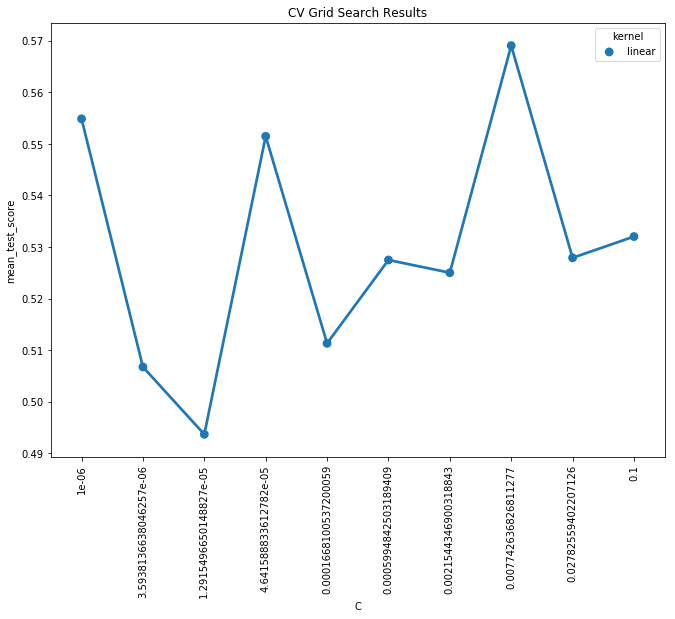

In [25]:
fig = plot_cv_results(locally_best_classifier.cv_results_, 'C' , 'kernel')

In [25]:
# GridSearch results
params = {'C': 0.007742636826811277, 'kernel': 'linear'}
clf = SVC(**params)

In [26]:
clf.fit(X_cv_train, y_cv_train)

SVC(C=0.007742636826811277, cache_size=None, class_weight={}, coef0=0.0,
    decision_function_shape='ovo', degree=3, gamma='auto', gpu_id=0,
    kernel='linear', max_iter=-1, max_mem_size=-1, n_jobs=-1, probability=False,
    random_state=None, shrinking=False, tol=0.001, verbose=False)

In [27]:
pred_cv = clf.decision_function(X_cv_test)
roc_auc_score(y_cv_test, pred_cv)

0.5936304400611373

## Trying SGDClassifier with hinge loss

In [28]:
X_train, X_test, y_train, y_test = \
    train_test_split(df.loc[:,
                            (df.columns != 'Delinquent90')],
                     df['Delinquent90'], test_size=0.3)

In [29]:
svm = SGDClassifier(n_jobs=-1)
svm.fit(X_train,y_train)

SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0, fit_intercept=True,
              l1_ratio=0.15, learning_rate='optimal', loss='hinge',
              max_iter=1000, n_iter_no_change=5, n_jobs=-1, penalty='l2',
              power_t=0.5, random_state=None, shuffle=True, tol=0.001,
              validation_fraction=0.1, verbose=0, warm_start=False)

In [30]:
svm.score(X_train, y_train)

0.9349285714285714

In [31]:
svm.score(X_test, y_test)

0.9331111111111111

Much better than SVM:

In [32]:
prediction = svm.decision_function(X_test)
roc_auc_score(y_test, prediction)

0.7998947250796611

### Seems better, trying GridSearchCV

In [33]:
svm_params = {
    'alpha': np.logspace(-6, 6, 10),
    'learning_rate': ['constant'],
    'eta0': np.logspace(-6, 0, 5)
}

locally_best_classifier = GridSearchCV(
    SGDClassifier(),
    svm_params,
    verbose=1,
    n_jobs=8,
    cv=5,
    scoring='roc_auc'
).fit(X_cv_train, y_cv_train)

print("Best params:", locally_best_classifier.best_params_)
print("Best cross validaton score", locally_best_classifier.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    4.6s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:   14.0s
[Parallel(n_jobs=8)]: Done 250 out of 250 | elapsed:   17.5s finished


Best params: {'alpha': 2.1544346900318823e-05, 'eta0': 1e-06, 'learning_rate': 'constant'}
Best cross validaton score 0.7523715822700859


### GridSearch parameters: dependence on alpha for different learning rates

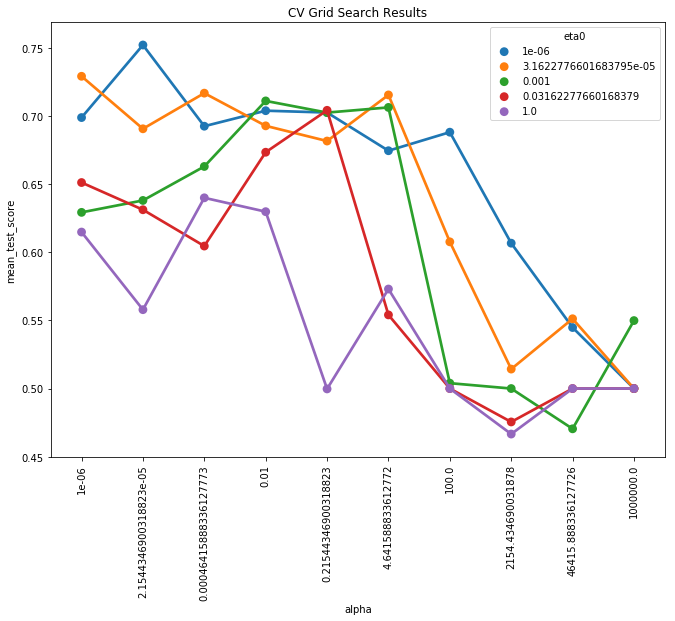

In [34]:
fig = plot_cv_results(locally_best_classifier.cv_results_,'alpha','eta0')

In [35]:
pred_cv = locally_best_classifier.best_estimator_.decision_function(X_cv_test)
roc_auc_score(y_cv_test, pred_cv)

0.7660193086687783

### Choosing slightly different parameters, GridSearch seems to be overfitting

In [36]:
svm = SGDClassifier(n_jobs=-1, alpha=1e-4,
                    learning_rate='constant',
                    eta0=0.1, shuffle=True)

svm.fit(X_train, y_train)

SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.1, fit_intercept=True,
              l1_ratio=0.15, learning_rate='constant', loss='hinge',
              max_iter=1000, n_iter_no_change=5, n_jobs=-1, penalty='l2',
              power_t=0.5, random_state=None, shuffle=True, tol=0.001,
              validation_fraction=0.1, verbose=0, warm_start=False)

Still, about the same as with the default parameters:

In [37]:
prediction = svm.decision_function(X_test)
roc_auc_score(y_test, prediction)

0.7933195723535856

### Plotting averaged ROC-AUC for these values

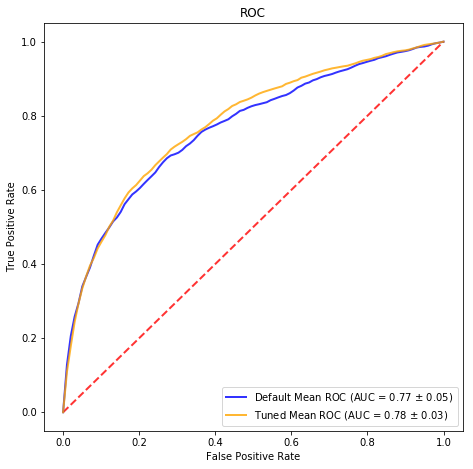

In [38]:
X, y = df.loc[:, (df.columns != 'Delinquent90')].to_numpy(),\
    df['Delinquent90'].to_numpy()

# Default classifier
classifier = SGDClassifier(n_jobs=-1)

cv = StratifiedKFold(n_splits=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0

for train, test in cv.split(X, y):
    probas_ = classifier.fit(X[train], y[train]).decision_function(X[test])
    # Compute ROC curve and area the curve
    fpr, tpr, thresholds = roc_curve(y[test], probas_)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    i += 1

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)


plt.figure(figsize=(7.5, 7.5))
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', alpha=.8)


plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Default Mean ROC (AUC = %0.2f $\pm$ %0.2f)' %
         (mean_auc, std_auc),
         lw=2, alpha=.8)

# GridSearchCV results
# classifier=locally_best_classifier.best_estimator_
classifier = SGDClassifier(n_jobs=-1, alpha=1e-3,
                           learning_rate='constant',
                           eta0=0.15, shuffle=True)
cv = StratifiedKFold(n_splits=6)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)


i = 0
for train, test in cv.split(X, y):
    probas_ = classifier.fit(X[train], y[train]).decision_function(X[test])
    # Compute ROC curve and area the curve
    fpr, tpr, thresholds = roc_curve(y[test], probas_)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    i += 1

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='orange',
         label=r'Tuned Mean ROC (AUC = %0.2f $\pm$ %0.2f)' %
         (mean_auc, std_auc),
         lw=2, alpha=.8)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.legend(loc="lower right")
plt.show()

### Seems a bit better ^

## As per sklearn recommendations, trying to implement different kernels with Nystroem transform

In [39]:
X_train, X_test, y_train, y_test = \
    train_test_split(df.loc[:,
                            (df.columns != 'Delinquent90')],
                     df['Delinquent90'], test_size=0.3)

### RBF kernel [default]

In [40]:
clf = LinearSVC()
feature_map_nystroem = Nystroem(gamma=.02,
                                random_state=1,
                                n_components=300)
data_transformed = feature_map_nystroem.fit_transform(X_train)
clf.fit(data_transformed, y_train)
clf.score(data_transformed, y_train) 

0.935

In [41]:
test_data_transformed = feature_map_nystroem.transform(X_test)

In [42]:
prediction=clf.decision_function(test_data_transformed)
roc_auc_score(y_test, prediction)

0.8207310120923988

## GridSearchCV with SVC [RBF kernel]

In [50]:
svm_params = {
    'kernel': ['rbf'],
    'C': np.logspace(-1, 1, 5),
    'max_iter': [10000],
    'gamma': np.logspace(-2, 2, 10),
    'cache_size': [16000]
}

locally_best_classifier = GridSearchCV(
    SVC(),
    svm_params,
    verbose=100,
    n_jobs=8,
    cv=5,
    scoring='roc_auc'
).fit(X_cv_train, y_cv_train)

print("Best params:", locally_best_classifier.best_params_)
print("Best cross validaton score", locally_best_classifier.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
Memmapping (shape=(42000, 79), dtype=float64) to new file /dev/shm/joblib_memmapping_folder_15529_1828894235/15529-140609853581912-75830716d2ea41c890ad114b03c92e4b.pkl
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(33599,), dtype=int64).
Pickling array (shape=(8401,), dtype=int64).
Memmapping (shape=(42000, 79), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_15529_1828894235/15529-140609853581912-75830716d2ea41c890ad114b03c92e4b.pkl
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(33600,), dtype=int64).
Pickling array (shape=(8400,), dtype=int64).
Memmapping (shape=(42000, 79), dtype=float64) to old file /dev/shm/jo

[Parallel(n_jobs=8)]: Done  11 tasks      | elapsed:  2.0min
Memmapping (shape=(42000, 79), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_15529_1828894235/15529-140609853581912-75830716d2ea41c890ad114b03c92e4b.pkl
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(33601,), dtype=int64).
Pickling array (shape=(8399,), dtype=int64).
[Parallel(n_jobs=8)]: Done  12 tasks      | elapsed:  2.0min
Memmapping (shape=(42000, 79), dtype=float64) to old file /dev/shm/joblib_memmapping_folder_15529_1828894235/15529-140609853581912-75830716d2ea41c890ad114b03c92e4b.pkl
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(42000,), dtype=int64).
Pickling array (shape=(33599,), dtype=int64).
Pickling array (shape=(8401,), dtype=int64).
[Parallel(n_jobs=8)]: Done  13 tasks      | elapsed:  2.0min
Memmapping (shape=(4200

KeyboardInterrupt: 

GridSearch best params:

In [51]:
params = {'C': 3.1622776601683795, 'cache_size': 16000,
          'gamma': 35.93813663804626, 'kernel': 'rbf',
          'max_iter': 10000}

In [52]:
clf = SVC(**params)
clf.fit(X_cv_train, y_cv_train)

SVC(C=3.1622776601683795, cache_size=16000, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma=35.93813663804626,
    kernel='rbf', max_iter=10000, probability=False, random_state=None,
    shrinking=True, tol=0.001, verbose=False)

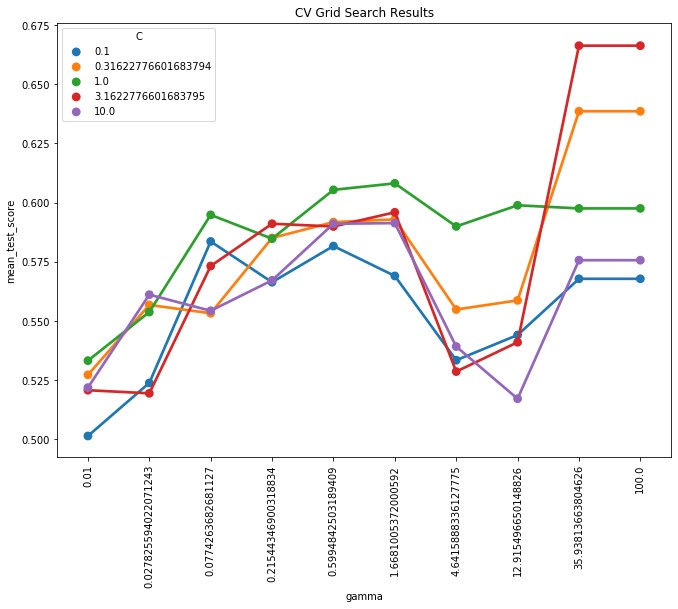

In [60]:
fig1 = plot_cv_results(locally_best_classifier.cv_results_,
                       'gamma', 'C')

In [54]:
roc_auc_score(y_cv_test,
              clf.decision_function(X_cv_test))

0.6576214602508766

In [55]:
svm = SVC(kernel='rbf', gamma=1.66,
          C=1, max_iter=10000, cache_size=10000)

svm.fit(X_train, y_train)
roc_auc_score(y_test, svm.decision_function(X_test))

0.599691388074483

In [56]:
svm = SVC(kernel='rbf', gamma=5e-2,
          C=1000, max_iter=10000, cache_size=10000)

svm.fit(X_train, y_train)
roc_auc_score(y_test,svm.decision_function(X_test))

0.7023804894845688

It seems that the result of GridSearchCV is not necessarily the best for the ROC-AUC estimation on test data

## Plotting ROC-AUC vs C for different kernels

Taking a subset of the data:

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
   df.loc[:, (df.columns != 'Delinquent90')], df['Delinquent90'], test_size=0.75)

X_cv_train, X_cv_test, y_cv_train, y_cv_test = train_test_split(
   X_train, y_train, test_size=0.3)

In [58]:
C = np.logspace(-1, 5, 20)
kernels = ['linear', 'poly', 'rbf']
train_results = {}
test_results = {}

for i in range(len(C)):
    for k in kernels:
        clf = SVC(kernel=k, C=C[i], max_iter=10000, gamma=1)
        clf.fit(X_cv_train, y_cv_train)
        train_pred = clf.decision_function(X_cv_train)
        false_positive_rate, true_positive_rate, thresholds = \
            roc_curve(y_cv_train, train_pred)
        roc_auc = auc(false_positive_rate, true_positive_rate)
        # Add auc score to previous train results
        if k not in train_results.keys():
            train_results[k] = np.zeros(len(C))
            train_results[k][i] = roc_auc
        else:
            train_results[k][i] = roc_auc
        y_pred = clf.predict(X_cv_test)
        false_positive_rate, true_positive_rate, thresholds = \
            roc_curve(y_cv_test, y_pred)
        roc_auc = auc(false_positive_rate, true_positive_rate)
        # Add auc score to previous test results
        if k not in test_results.keys():
            test_results[k] = np.zeros(len(C))
            test_results[k][i] = roc_auc
        else:
            test_results[k][i]=roc_auc
    print('C:',C[i])

C: 0.1
C: 0.20691380811147897
C: 0.42813323987193935
C: 0.8858667904100825
C: 1.8329807108324356
C: 3.79269019073225
C: 7.847599703514611
C: 16.23776739188721
C: 33.59818286283781
C: 69.51927961775606
C: 143.8449888287663
C: 297.6351441631316
C: 615.8482110660261
C: 1274.2749857031322
C: 2636.6508987303555
C: 5455.594781168515
C: 11288.378916846883
C: 23357.21469090121
C: 48329.30238571752
C: 100000.0


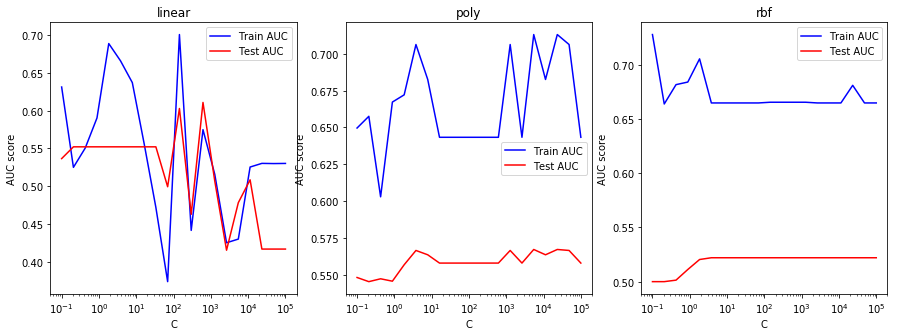

In [59]:
fig, axs = plt.subplots(1,3,figsize=(15,5))

for i in range(len(axs)):
    axs[i].semilogx(C, train_results[kernels[i]], 'b', label='Train AUC')
    axs[i].semilogx(C, test_results[kernels[i]], 'r', label='Test AUC')
    axs[i].legend()
    axs[i].set_title(kernels[i])
    axs[i].set_ylabel('AUC score')
    axs[i].set_xlabel('C')

### Seems like the linear kernel is still producing the best score